# Understanding Distributions in Financial Returns

## Abstract
This notebook analyzes...

##  1. Setup and Imports

In [2]:
# Install required packages (run once)
!pip install yfinance 

In [3]:
pip install scipy pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [5]:
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: '%.4f' % x)

## 2. Theory Background
## Key Concepts:
### - **Return**: Percentage change in price
### - **Normal Distribution**: Bell-shaped curve where extreme events are rare
### - **Skewness**: Measures asymmetry (negative = more extreme losses)
### - **Kurtosis**: Measures tail thickness (higher = more extreme events)
### **For a normal distribution:**
### - Skewness = 0
### - Excess Kurtosis = 0

##  3. Problem Statement
### We want to answer: **Do financial returns follow a normal distribution?**
### **Input:** Historical daily prices  
### **Output:** Statistics, visualizations, and normality test results

In [8]:
#Data Preprocessing 

In [21]:
#S&P 500 data
sp500 = yf.download("^GSPC", start="2014-01-01", end="2024-01-01", progress=False)
sp500_prices = sp500['Close']

In [23]:
#Bitcoin data
btc = yf.download("BTC-USD", start="2014-01-01", end="2024-01-01", progress=False)
btc_prices = btc['Close']

In [25]:
print(f"S&P 500: {len(sp500_prices)} trading days")
print(f"Bitcoin: {len(btc_prices)} trading days")

S&P 500: 2516 trading days
Bitcoin: 3393 trading days


In [29]:
# Calculate log returns
sp500_returns = np.log(sp500_prices / sp500_prices.shift(1)).dropna()
btc_returns = np.log(btc_prices / btc_prices.shift(1)).dropna()

In [31]:
print(f"S&P 500 returns: {len(sp500_returns)} observations")
print(f"Bitcoin returns: {len(btc_returns)} observations")

S&P 500 returns: 2515 observations
Bitcoin returns: 3392 observations


In [45]:
# missing values
print(f"S&P 500 missing values: {sp500_returns.isna().sum().item()}")
print(f"Bitcoin missing values: {btc_returns.isna().sum().item()}")

S&P 500 missing values: 0
Bitcoin missing values: 0


In [47]:
print("\nS&P 500 Returns (first 5 rows):")
print(sp500_returns.head())


S&P 500 Returns (first 5 rows):
Ticker       ^GSPC
Date              
2014-01-03 -0.0003
2014-01-06 -0.0025
2014-01-07  0.0061
2014-01-08 -0.0002
2014-01-09  0.0003


In [57]:
def calculate_statistics(returns, name):
    """Calculate and display key statistics."""
    
    returns = returns.values.flatten()
    
    statistics = {
        'Mean (%)': np.mean(returns) * 100,
        'Std Dev (%)': np.std(returns) * 100,
        'Skewness': stats.skew(returns),
        'Excess Kurtosis': stats.kurtosis(returns),
        'Min (%)': np.min(returns) * 100,
        'Max (%)': np.max(returns) * 100
    }
    
    print(f"\n=== {name} Statistics ===")
    for key, value in statistics.items():
        print(f"{key}: {value:.4f}")
    
    return statistics

sp500_stats = calculate_statistics(sp500_returns, "S&P 500")
btc_stats = calculate_statistics(btc_returns, "Bitcoin") 


=== S&P 500 Statistics ===
Mean (%): 0.0380
Std Dev (%): 1.1211
Skewness: -0.8088
Excess Kurtosis: 16.0445
Min (%): -12.7652
Max (%): 8.9683

=== Bitcoin Statistics ===
Mean (%): 0.1334
Std Dev (%): 3.7267
Skewness: -0.7628
Excess Kurtosis: 11.4187
Min (%): -46.4730
Max (%): 22.5119


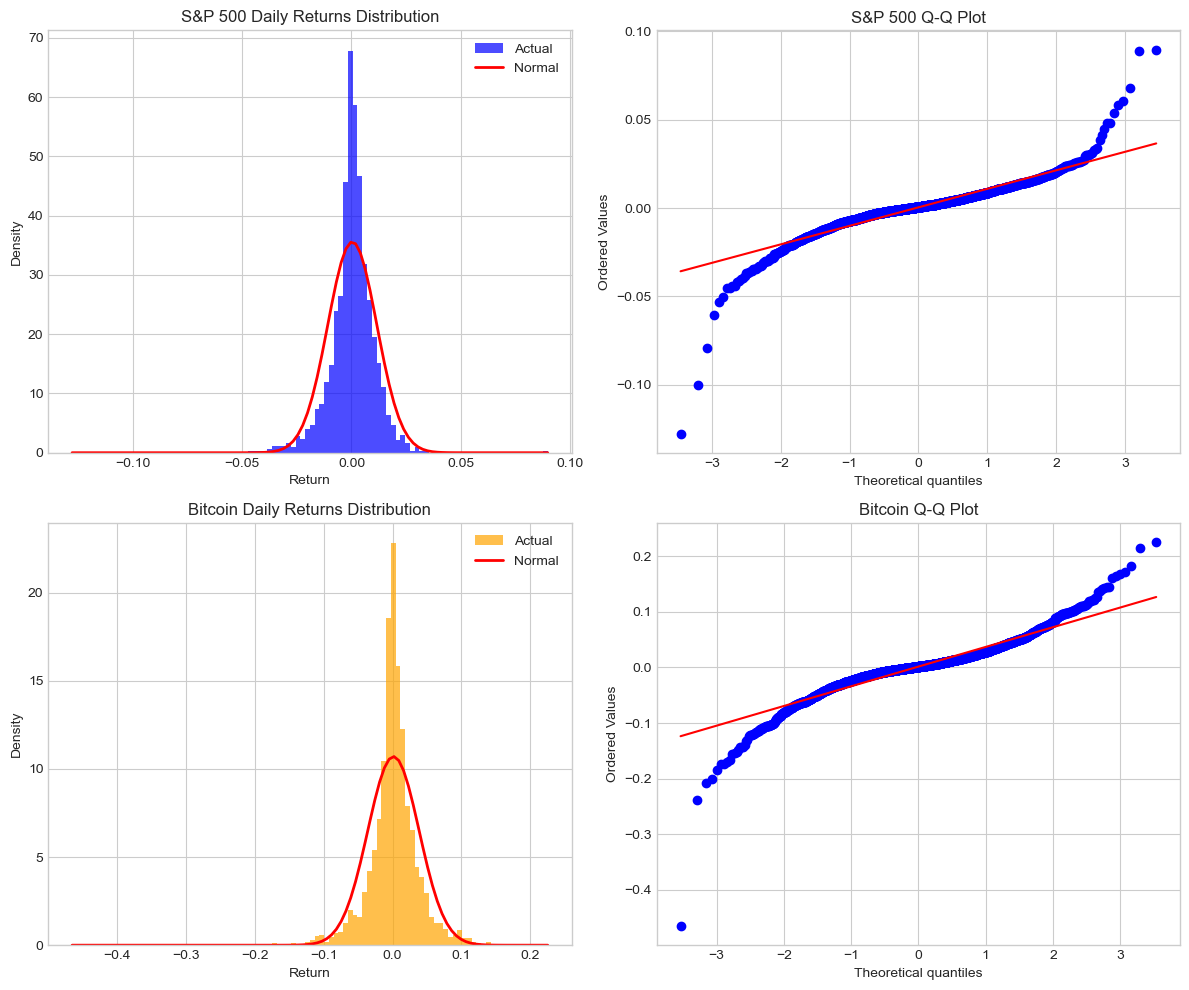

In [73]:
# Flatten data to 1D arrays
sp500_ret = sp500_returns.values.flatten()
btc_ret = btc_returns.values.flatten()

# Visualize distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# S&P 500 Histogram
axes[0, 0].hist(sp500_ret, bins=100, density=True, alpha=0.7, color='blue', label='Actual')
x = np.linspace(sp500_ret.min(), sp500_ret.max(), 100)
axes[0, 0].plot(x, stats.norm.pdf(x, sp500_ret.mean(), sp500_ret.std()), 'r-', lw=2, label='Normal')
axes[0, 0].set_title('S&P 500 Daily Returns Distribution')
axes[0, 0].set_xlabel('Return')
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend()

# S&P 500 Q-Q Plot
stats.probplot(sp500_ret, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('S&P 500 Q-Q Plot')

# Bitcoin Histogram
axes[1, 0].hist(btc_ret, bins=100, density=True, alpha=0.7, color='orange', label='Actual')
x = np.linspace(btc_ret.min(), btc_ret.max(), 100)
axes[1, 0].plot(x, stats.norm.pdf(x, btc_ret.mean(), btc_ret.std()), 'r-', lw=2, label='Normal')
axes[1, 0].set_title('Bitcoin Daily Returns Distribution')
axes[1, 0].set_xlabel('Return')
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend()

# Bitcoin Q-Q Plot
stats.probplot(btc_ret, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Bitcoin Q-Q Plot')

plt.tight_layout()
plt.savefig('distributions.png', dpi=150)
plt.show()

In [75]:
# normality test
def normality_tests(returns, name):
    """Perform normality tests."""
    print(f"\n=== {name} Normality Tests ===")
    
    # Jarque-Bera Test
    jb_stat, jb_pvalue = stats.jarque_bera(returns)
    print(f"Jarque-Bera Test: statistic={jb_stat:.2f}, p-value={jb_pvalue:.2e}")
    
    # Shapiro-Wilk Test (sample if too large)
    sample = returns[:5000] if len(returns) > 5000 else returns
    sw_stat, sw_pvalue = stats.shapiro(sample)
    print(f"Shapiro-Wilk Test: statistic={sw_stat:.4f}, p-value={sw_pvalue:.2e}")
    
    # Interpretation
    alpha = 0.05
    if jb_pvalue < alpha:
        print(f"Result: REJECT normality (p < {alpha})")
    else:
        print(f"Result: Cannot reject normality (p >= {alpha})")

normality_tests(sp500_returns, "S&P 500")
normality_tests(btc_returns, "Bitcoin")


=== S&P 500 Normality Tests ===
Jarque-Bera Test: statistic=27250.41, p-value=0.00e+00
Shapiro-Wilk Test: statistic=0.8739, p-value=4.16e-41
Result: REJECT normality (p < 0.05)

=== Bitcoin Normality Tests ===
Jarque-Bera Test: statistic=18756.82, p-value=0.00e+00
Shapiro-Wilk Test: statistic=0.9018, p-value=3.11e-42
Result: REJECT normality (p < 0.05)


In [83]:
#tail analysis

def tail_analysis(returns, name):
    """Compare actual vs expected extreme events."""

    returns = returns.values.flatten()
    std = returns.std()
    
    print(f"\n=== {name} Tail Analysis ===")
    print(f"{'Event':<20} {'Actual':<10} {'Normal Expects':<15} {'Ratio':<10}")
    print("-" * 55)
    
    for n_std in [2, 3, 4]:
        actual = (np.abs(returns) > n_std * std).sum()
        expected = len(returns) * 2 * (1 - stats.norm.cdf(n_std))
        ratio = actual / expected if expected > 0 else np.inf
        print(f"Beyond {n_std} std dev     {actual:<10} {expected:<15.1f} {ratio:<10.1f}x")

tail_analysis(sp500_returns, "S&P 500")
tail_analysis(btc_returns, "Bitcoin")


=== S&P 500 Tail Analysis ===
Event                Actual     Normal Expects  Ratio     
-------------------------------------------------------
Beyond 2 std dev     114        114.4           1.0       x
Beyond 3 std dev     36         6.8             5.3       x
Beyond 4 std dev     17         0.2             106.7     x

=== Bitcoin Tail Analysis ===
Event                Actual     Normal Expects  Ratio     
-------------------------------------------------------
Beyond 2 std dev     191        154.3           1.2       x
Beyond 3 std dev     54         9.2             5.9       x
Beyond 4 std dev     19         0.2             88.4      x


## 8. Conclusion
## 1. Both S&P 500 and Bitcoin returns show **negative skewness** and **excess kurtosis**
### 2. Normality tests **reject** the normal distribution hypothesis
### 3. Extreme events occur **more frequently** than the normal distribution predicts 
### **Implications**:
### - Risk models assuming normality will underestimate tail risk
### - Investors should account for fat tails when assessing portfolio risk
 
### **Future Work:**
### - Analysis could be extended by fitting alternative distributions (like Student's t) that better capture fat tails, and by using time-series models (like GARCH) to study how volatile periods  tend to cluster together.


### 9. References & License 
#### **References:**
#### 1. Mandelbrot, B. (1963). "The Variation of Certain Speculative Prices."
#### 2. Cont, R. (2001). "Empirical Properties of Asset Returns."
#### 3. Yahoo Finance - Historical data
#### **License:** MIT License - Free to use and modify with attribution